In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('Dataset .csv', encoding='utf-8')
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

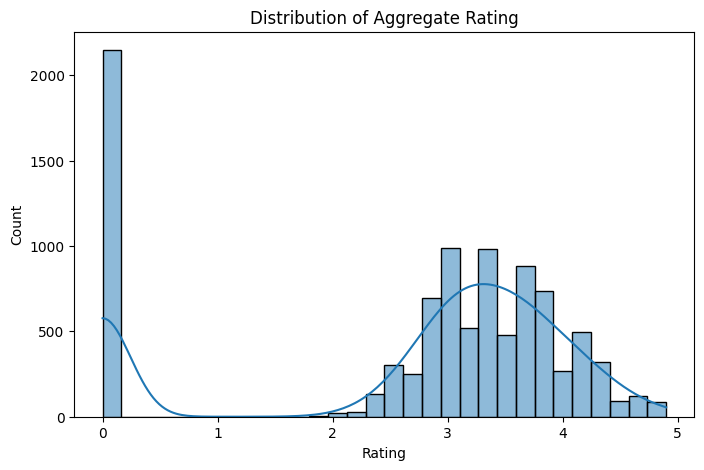

In [4]:
df.info()
missing = df.isnull().sum()
missing[missing > 0]
plt.figure(figsize=(8,5))
sns.histplot(df['Aggregate rating'], bins=30, kde=True)
plt.title('Distribution of Aggregate Rating')
plt.xlabel('Rating')
plt.show()

In [5]:
df = df.dropna(subset=['Aggregate rating'])
df.reset_index(drop=True, inplace=True)
selected_columns = [
    'Country Code', 'City', 'Cuisines', 'Average Cost for two', 'Currency',
    'Has Table booking', 'Has Online delivery', 'Is delivering now',
    'Price range', 'Votes', 'Aggregate rating'
]
df = df[selected_columns].copy()
print("Shape after selection:", df.shape)

Shape after selection: (9551, 11)


In [6]:
df.isnull().sum()
df = df.dropna().reset_index(drop=True)
print("Shape after dropping missing features:", df.shape)

Shape after dropping missing features: (9542, 11)


In [7]:
df['Cuisines'] = df['Cuisines'].fillna('Unknown')
cuisines_split = df['Cuisines'].str.split(', ')
all_cuisines = [item for sublist in cuisines_split for item in sublist]
top_cuisines = pd.Series(all_cuisines).value_counts().head(20).index.tolist()
print("Top 20 cuisines:", top_cuisines)
for cuisine in top_cuisines:
    df[f'Cuisine_{cuisine}'] = df['Cuisines'].apply(lambda x: 1 if cuisine in x else 0)
df.drop('Cuisines', axis=1, inplace=True)
df.head()

Top 20 cuisines: ['North Indian', 'Chinese', 'Fast Food', 'Mughlai', 'Italian', 'Bakery', 'Continental', 'Cafe', 'Desserts', 'South Indian', 'Street Food', 'American', 'Pizza', 'Mithai', 'Burger', 'Thai', 'Asian', 'Beverages', 'Ice Cream', 'Mexican']


,Country Code,City,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Votes,Aggregate rating,Cuisine_North Indian,Cuisine_Chinese,Cuisine_Fast Food,Cuisine_Mughlai,Cuisine_Italian,Cuisine_Bakery,Cuisine_Continental,Cuisine_Cafe,Cuisine_Desserts,Cuisine_South Indian,Cuisine_Street Food,Cuisine_American,Cuisine_Pizza,Cuisine_Mithai,Cuisine_Burger,Cuisine_Thai,Cuisine_Asian,Cuisine_Beverages,Cuisine_Ice Cream,Cuisine_Mexican
0,162,Makati City,1100,Botswana Pula(P),Yes,No,No,3,314,4.8,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
1,162,Makati City,1200,Botswana Pula(P),Yes,No,No,3,591,4.5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,162,Mandaluyong City,4000,Botswana Pula(P),Yes,No,No,4,270,4.4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,162,Mandaluyong City,1500,Botswana Pula(P),No,No,No,4,365,4.9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,162,Mandaluyong City,1500,Botswana Pula(P),Yes,No,No,4,229,4.8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
X = df.drop('Aggregate rating', axis=1)
y = df['Aggregate rating']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9542, 29)
Target shape: (9542,)


In [9]:
numeric_features = ['Average Cost for two', 'Votes', 'Price range'] + \
                   [col for col in X.columns if col.startswith('Cuisine_')]
categorical_features = ['Country Code', 'City', 'Currency',
                        'Has Table booking', 'Has Online delivery', 'Is delivering now']
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Average Cost for two', 'Votes', 'Price range', 'Cuisine_North Indian', 'Cuisine_Chinese', 'Cuisine_Fast Food', 'Cuisine_Mughlai', 'Cuisine_Italian', 'Cuisine_Bakery', 'Cuisine_Continental', 'Cuisine_Cafe', 'Cuisine_Desserts', 'Cuisine_South Indian', 'Cuisine_Street Food', 'Cuisine_American', 'Cuisine_Pizza', 'Cuisine_Mithai', 'Cuisine_Burger', 'Cuisine_Thai', 'Cuisine_Asian', 'Cuisine_Beverages', 'Cuisine_Ice Cream', 'Cuisine_Mexican']
Categorical features: ['Country Code', 'City', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 7633, Test size: 1909


In [11]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [12]:
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', LinearRegression())])
lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)
print("Linear Regression:\n  MSE: {:.4f}\n  R²:  {:.4f}".format(mse_lr, r2_lr))

Linear Regression:
  MSE: 1.4026
  R²:  0.3875


In [13]:
dt_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', DecisionTreeRegressor(random_state=42))])
dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
print("Decision Tree Regressor:\n  MSE: {:.4f}\n  R²:  {:.4f}".format(mse_dt, r2_dt))

Decision Tree Regressor:
  MSE: 0.1651
  R²:  0.9279


In [14]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(random_state=42, n_estimators=100))])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regressor:\n  MSE: {:.4f}\n  R²:  {:.4f}".format(mse_rf, r2_rf))

Random Forest Regressor:
  MSE: 0.0953
  R²:  0.9584


In [15]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'MSE': [mse_lr, mse_dt, mse_rf],
    'R²': [r2_lr, r2_dt, r2_rf]
})
print(results)

               Model       MSE        R²
0  Linear Regression  1.402634  0.387505
1      Decision Tree  0.165069  0.927919
2      Random Forest  0.095266  0.958400


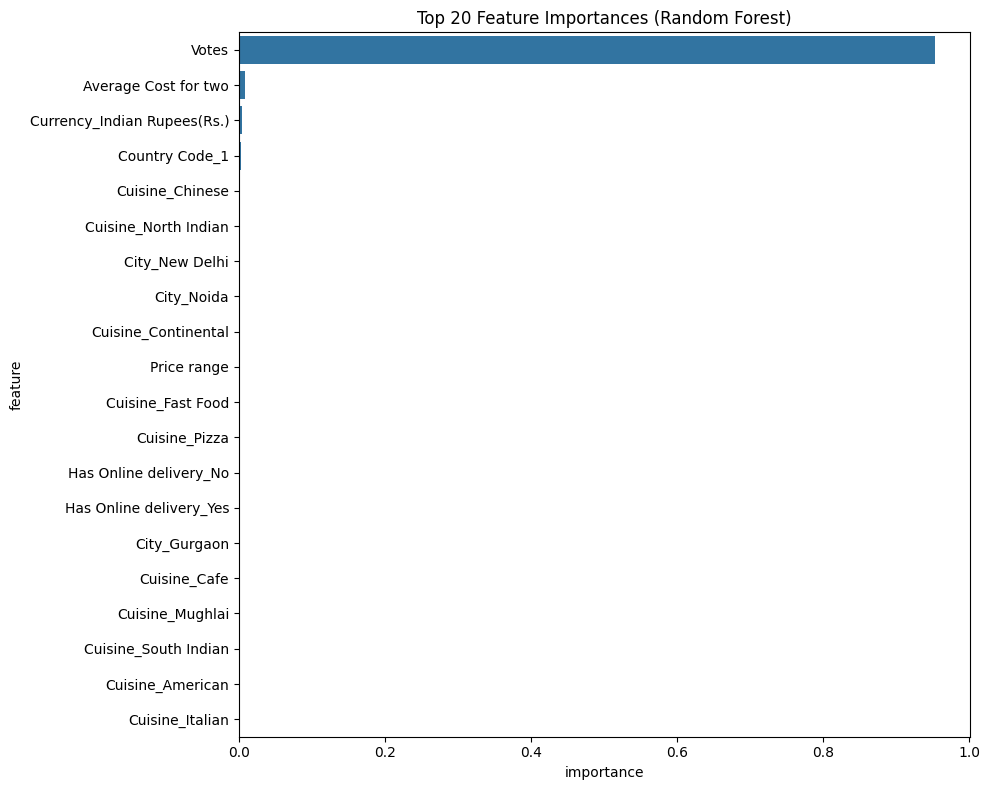

In [16]:
numeric_feature_names = numeric_features
cat_feature_names = list(rf_pipeline.named_steps['preprocessor']
                         .named_transformers_['cat']
                         .named_steps['onehot']
                         .get_feature_names_out(categorical_features))
all_feature_names = numeric_feature_names + cat_feature_names
importances = rf_pipeline.named_steps['regressor'].feature_importances_
importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10,8))
sns.barplot(data=importance_df.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [17]:
new_restaurant_base = {
    'Country Code': 1,
    'City': 'New Delhi',
    'Average Cost for two': 800,
    'Currency': 'Indian Rupees(Rs.)',
    'Has Table booking': 'Yes',
    'Has Online delivery': 'No',
    'Is delivering now': 'No',
    'Price range': 3,
    'Votes': 150
}

for cuisine in top_cuisines:
    new_restaurant_base[f'Cuisine_{cuisine}'] = 0

cuisines_served = ['North Indian', 'Chinese']
for cuisine in cuisines_served:
    new_restaurant_base[f'Cuisine_{cuisine}'] = 1

# Convert to DataFrame
new_df = pd.DataFrame([new_restaurant_base])

# Ensure columns are in the same order as X_train
expected_columns = X_train.columns.tolist()
new_df = new_df[expected_columns]

# Predict
predicted_rating = rf_pipeline.predict(new_df)[0]
print(f"Predicted Aggregate Rating for the new restaurant: {predicted_rating:.2f}")

Predicted Aggregate Rating for the new restaurant: 3.43


In [18]:
import joblib

joblib.dump(rf_pipeline, 'restaurant_rating_model.pkl')
print("Model saved as 'restaurant_rating_model.pkl'")

Model saved as 'restaurant_rating_model.pkl'


In [19]:
loaded_model = joblib.load('restaurant_rating_model.pkl')

if 'new_df' not in locals():
    new_restaurant_base = {
        'Country Code': 1,
        'City': 'New Delhi',
        'Average Cost for two': 800,
        'Currency': 'Indian Rupees(Rs.)',
        'Has Table booking': 'Yes',
        'Has Online delivery': 'No',
        'Is delivering now': 'No',
        'Price range': 3,
        'Votes': 150
    }
    for cuisine in top_cuisines:
        new_restaurant_base[f'Cuisine_{cuisine}'] = 0
    cuisines_served = ['North Indian', 'Chinese']   # Modify as needed
    for cuisine in cuisines_served:
        new_restaurant_base[f'Cuisine_{cuisine}'] = 1
    new_df = pd.DataFrame([new_restaurant_base])
    new_df = new_df[X_train.columns.tolist()]

predicted_rating_loaded = loaded_model.predict(new_df)[0]
print(f"Predicted rating from loaded model: {predicted_rating_loaded:.2f}")

Predicted rating from loaded model: 3.43
